 # Deep Learning - Assignment 3
 ## Lyrics Generation using RNNs

 **Student Names:** Yuriy Rusanov, Elad Orpaz

 **ID(s):** 340915149, 206216517

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import pretty_midi
import os
import re
import random
from tqdm import tqdm
from gensim.models import Word2Vec

In [11]:
# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midi_files_dir = 'data/midi_files'

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


## 1. Data Preparation

### 1.1. Data Loading and Preprocessing

In [4]:
# Load lyrics data
def load_lyrics_data(file_path):
    """Load Lyrics data from CSV file"""
    df = pd.read_csv(file_path, header=None, usecols=[0, 1, 2])
    df.columns = ['artist', 'song', 'lyrics']
    return df


def is_problematic(row):
    # List of known problematic files (patterns to match in filenames)
    problematic_patterns = [
        ('beastie boys', 'girls'),
        ('billy joel', 'movin\' out'),
        ('billy joel', 'pressure'),
        ('dan fogelberg', 'leader of the band'),
        ('brian mcknight', 'on the down low'),
        ('aaron neville', 'tell it like it is'),
    ]

    return (row['artist'].lower(), row['song'].lower()) in problematic_patterns


train_lyrics = load_lyrics_data('data/lyrics_train_set.csv')
train_lyrics = train_lyrics[~train_lyrics.apply(is_problematic, axis=1)].reset_index(drop=True)

test_lyrics = load_lyrics_data('data/lyrics_test_set.csv')

print("Training data shape:", train_lyrics.shape)
print("Test data shape:", test_lyrics.shape)

Training data shape: (594, 3)
Test data shape: (5, 3)


### 1.2. Tokenization

In [5]:
def preprocess_lyrics(lyrics_series):
    """Preprocess and tokenize lyrics."""
    all_lyrics = []
    for lyric in lyrics_series:
        # Convert to lowercase and split into lines
        lyric = str(lyric).lower()
        lines = lyric.split('&')

        # Process each line
        for line in lines:
            # Clean and tokenize
            # tokens = re.findall(r'\b\w+\b', line)
            tokens = re.findall(r"\b\w+(?:'\w+)*\b", line)
            if tokens:  # Skip empty lines
                all_lyrics.append(tokens)

    return all_lyrics


# Process train and test lyrics
train_tokenized = preprocess_lyrics(train_lyrics.iloc[:, 2])
test_tokenized = preprocess_lyrics(test_lyrics.iloc[:, 2])

print(f"Number of lines in training set: {len(train_tokenized)}")
print(f"Number of lines in test set: {len(test_tokenized)}")

Number of lines in training set: 23659
Number of lines in test set: 189


### 1.3. Word Embeddings

In [15]:
def build_vocabulary(tokenized_lyrics, min_freq):
    """Build vocabulary from tokenized lyrics."""
    word_counts = Counter()
    for line in tokenized_lyrics:
        word_counts.update(line)

    vocab = {'<PAD>': 0, '<NEXT LINE>': 1, '<START>': 2, '<END>': 3}
    idx = 4
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab, word_counts


vocab, word_counts = build_vocabulary(train_tokenized, min_freq=1)
print(f"Vocabulary size: {len(vocab)}")
print(f"Top 10 most common words: {word_counts.most_common(10)}")

Vocabulary size: 7384
Top 10 most common words: [('you', 5898), ('the', 5805), ('i', 5290), ('to', 3733), ('and', 3654), ('a', 3063), ('me', 2817), ('my', 2161), ('it', 2051), ('in', 2039)]


In [16]:
embedding_dim = 300
window_size = 5
workers = 4

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=train_tokenized,
    vector_size=embedding_dim,
    window=window_size,
    min_count=1,
    workers=workers,
    sg=1,  # Skip-gram model
    epochs=20
)

print(f"Word2Vec model trained with vector size: {w2v_model.vector_size}")
print(f"Vocabulary size in Word2Vec model: {len(w2v_model.wv.key_to_index)}")


def create_embedding_matrix(vocab, embedding_model, embedding_dim=300):
    """Create embedding matrix for words in vocabulary."""
    embedding_matrix = np.zeros((len(vocab), embedding_dim))
    for word, idx in vocab.items():
        if word not in ['<PAD>', '<NEXT LINE>', '<START>', '<END>']:
            embedding_matrix[idx] = embedding_model.wv[word.lower()]

    # Special Tokens (<PAD> remains 0)
    for special_token in ['<NEXT LINE>', '<START>', '<END>']:
        embedding_matrix[vocab[special_token]] = np.random.uniform(-0.25, 0.25, embedding_dim)

    return embedding_matrix


embedding_matrix = create_embedding_matrix(vocab, w2v_model)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Word2Vec model trained with vector size: 300
Vocabulary size in Word2Vec model: 7380
Embedding matrix shape: (7384, 300)


### 1.4. Match Lyrics with MIDI Files

In [17]:
def create_lyrics_midi_mapping(lyrics_df, midi_dir):
    """Mapping lyrics to MIDI files."""
    mapping = []

    midi_files = os.listdir(midi_dir)

    # For each song in the lyrics dataset, find the matching MIDI file
    for idx, row in lyrics_df.iterrows():
        artist = row['artist'].strip().lower().replace(' ', '_')
        song = row['song'].strip().lower().replace(' ', '_')
        lyrics = row['lyrics']

        for midi_file in midi_files:
            midi_name = midi_file.lower()
            if artist in midi_name and song in midi_name:
                mapping.append({
                    'artist': artist,
                    'song': song,
                    'lyrics': lyrics,
                    'midi_file': os.path.join(midi_dir, midi_file)
                })
                break

    return mapping


# Create mapping for training and test data
train_mapping = create_lyrics_midi_mapping(train_lyrics, midi_files_dir)
test_mapping = create_lyrics_midi_mapping(test_lyrics, midi_files_dir)

print(f"Found matching MIDI files for {len(train_mapping)} out of {len(train_lyrics)} training songs")
print(f"Found matching MIDI files for {len(test_mapping)} out of {len(test_lyrics)} test songs")

Found matching MIDI files for 594 out of 594 training songs
Found matching MIDI files for 5 out of 5 test songs


## 2.Simple Model

### 2.1. Dataset

In [23]:
def load_simple_midi_features(midi_file_path):
    """Extract features from a MIDI file using pretty_midi."""
    midi_data = pretty_midi.PrettyMIDI(midi_file_path)

    features = {}

    # Tempo information
    tempo_changes = midi_data.get_tempo_changes()
    features['tempo'] = np.mean(tempo_changes[1])

    notes = []

    # Note features
    for inst in midi_data.instruments:
        for note in inst.notes:
            notes.append({
                'pitch': note.pitch,
                'start': note.start,
                'end': note.end,
                'duration': note.end - note.start,
                'velocity': note.velocity
            })

        pitches = np.array([note['pitch'] for note in notes])
        durations = np.array([note['duration'] for note in notes])
        velocities = np.array([note['velocity'] for note in notes])
        features['avg_pitch'] = np.mean(pitches)
        features['pitch_std'] = np.std(pitches)
        features['pitch_range'] = np.max(pitches) - np.min(pitches)
        features['avg_duration'] = np.mean(durations)
        features['avg_velocity'] = np.mean(velocities)
        features['note_density'] = len(notes) / midi_data.get_end_time()

    return features

In [26]:
# Custom Dataset class
class LyricsMelodyDataset(Dataset):
    def __init__(self, mappings, vocab, max_sequence_length=50):
        self.mappings = mappings
        self.vocab = vocab
        self.max_sequence_length = max_sequence_length
        self.reverse_vocab = {v: k for k, v in vocab.items()}

        # Preprocess all data
        self.process_all_data()

    def process_all_data(self):
        """Process all data at initialization."""
        self.data = []

        for mapping in tqdm(self.mappings, desc="Processing data"):
            # Extract midi features
            midi_features = load_simple_midi_features(mapping['midi_file'])

            lyrics = str(mapping['lyrics']).lower()
            lines = lyrics.split('&')

            all_tokens = ['<START>']
            for line in lines:
                line_tokens = re.findall(r"\b\w+(?:'\w+)*\b", line)
                if line_tokens:
                    all_tokens.extend(line_tokens)
                    all_tokens.append('<NEXT LINE>')

            # Replace the last NEXT_LINE with END
            if all_tokens[-1] == '<NEXT LINE>':
                all_tokens[-1] = '<END>'
            else:
                all_tokens.append('<END>')

            indices = [self.vocab[token] for token in all_tokens]

            # Create input-target pairs across the entire sequence
            for i in range(len(indices) - 1):
                input_word = indices[i]
                target_word = indices[i + 1]

                # Add to data with melody features
                self.data.append({
                    'input_word': input_word,
                    'melody_features': midi_features,
                    'target_word': target_word,
                    'position': i,
                    'line_length': len(indices)
                })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Extract melody features
        melody_feats = np.array([
            item['melody_features']['avg_pitch'],
            item['melody_features']['pitch_std'],
            item['melody_features']['pitch_range'],
            item['melody_features']['avg_duration'],
            item['melody_features']['avg_velocity'],
            item['melody_features']['note_density'],
            item['melody_features']['tempo'] / 120.0,
        ])

        return {
            'input_word': torch.tensor(item['input_word'], dtype=torch.long),
            'melody_features': torch.tensor(melody_feats, dtype=torch.float),
            'target_word': torch.tensor(item['target_word'], dtype=torch.long),
        }

In [25]:
# Create dataset
full_dataset = LyricsMelodyDataset(train_mapping, vocab)

# Split into train and validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Processing data:   0%|          | 0/594 [00:00<?, ?it/s]C:\Users\rusanov\.conda\envs\DRL\Lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing data: 100%|██████████| 594/594 [00:51<00:00, 11.43it/s]

Train dataset size: 143243
Validation dataset size: 35811


### 2.2. Model

In [27]:
class LyricsMelodyGeneratorSimple(nn.Module):
    def __init__(self, vocab_size, embedding_dim, melody_dim, hidden_dim,
                 num_layers, dropout, pretrained_embeddings):
        super(LyricsMelodyGeneratorSimple, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Word embeddings - initialized from Word2Vec
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Melody feature projection
        self.melody_projection = nn.Linear(melody_dim, embedding_dim)

        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim * 2, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)

        # Output layer
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, word_input, melody_features, hidden=None):

        # Word and Melody embeddings
        word_emb = self.embedding(word_input)
        melody_emb = self.melody_projection(melody_features)
        combined_input = torch.cat([word_emb, melody_emb], dim=1).unsqueeze(1)

        # Pass through LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(combined_input)
        else:
            lstm_out, hidden = self.lstm(combined_input, hidden)

        # Apply dropout and project to vocabulary size
        output = self.dropout(lstm_out.squeeze(1))
        output = self.fc(output)

        return output, hidden

    def generate_lyrics(self, melody_features, reverse_vocab, max_length=50, start_word='<START>', temperature=1.0,
                        device='cpu'):
        """Generate lyrics given words and melody features."""
        self.eval()
        words = [start_word]
        hidden = None

        word_input = torch.tensor([vocab[start_word]]).to(device)
        melody_feat_tensor = torch.tensor(melody_features, dtype=torch.float).unsqueeze(0).to(device)

        for _ in range(max_length):
            output, hidden = self.forward(word_input, melody_feat_tensor, hidden)

            # Get word using temperature
            output = output.div(temperature)
            word_weights = output.squeeze().exp()
            word_idx = torch.multinomial(word_weights, 1)[0].item()
            word = reverse_vocab[word_idx]

            # End sequence
            if word == '<END>':
                break

            words.append(word)

            # Update input for next iteration
            word_input = torch.tensor([word_idx]).to(device)

        return words

### 2.3. Training

In [28]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            input_words = batch['input_word'].to(device)
            melody_features = batch['melody_features'].to(device)
            targets = batch['target_word'].to(device)

            outputs, _ = model(input_words, melody_features)
            loss = criterion(outputs, targets)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                input_words = batch['input_word'].to(device)
                melody_features = batch['melody_features'].to(device)
                targets = batch['target_word'].to(device)

                outputs, _ = model(input_words, melody_features)
                loss = criterion(outputs, targets)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

Epoch 1/50 - Validation: 100%|██████████| 560/560 [00:00<00:00, 606.58it/s]


Epoch 1/50, Train Loss: 6.0393, Val Loss: 5.9341
New best model saved!


Epoch 2/50 - Validation: 100%|██████████| 560/560 [00:00<00:00, 641.36it/s]


Epoch 2/50, Train Loss: 5.8216, Val Loss: 5.8224
New best model saved!


Epoch 3/50 - Validation: 100%|██████████| 560/560 [00:01<00:00, 483.04it/s]


...

Epoch 48/50, Train Loss: 5.1051, Val Loss: 5.4014


Epoch 49/50 - Validation: 100%|██████████| 560/560 [00:00<00:00, 762.32it/s]


Epoch 49/50, Train Loss: 5.1025, Val Loss: 5.4014


Epoch 50/50 - Validation: 100%|██████████| 560/560 [00:00<00:00, 748.47it/s]


Epoch 50/50, Train Loss: 5.1033, Val Loss: 5.4003
New best model saved!


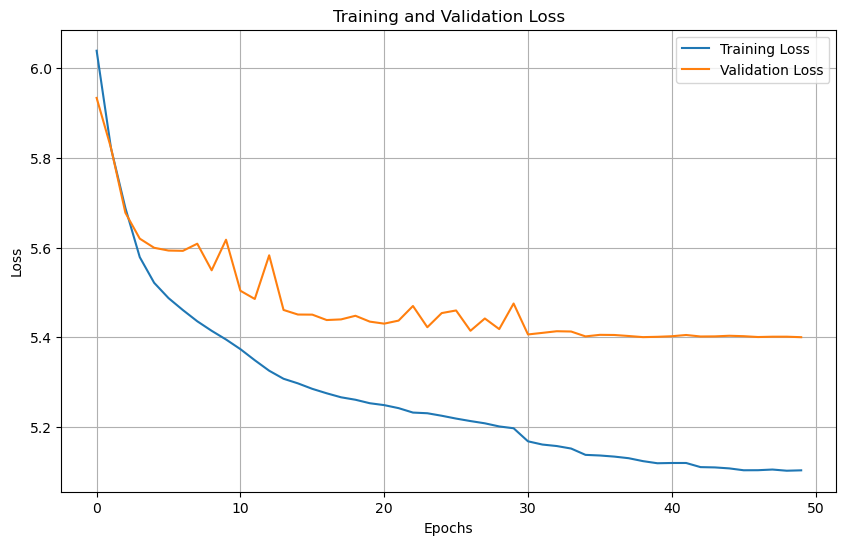

In [29]:
# Initialization
vocab_size = len(vocab)
embedding_dim = 300  # Word2Vec dimension
melody_dim = 7  # Number of melody features
hidden_dim = 512

model = LyricsMelodyGeneratorSimple(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    melody_dim=melody_dim,
    hidden_dim=hidden_dim,
    num_layers=4,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix
).to(device)

# Training
trained_model, train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    learning_rate=0.0001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### 2.4 Evaluation

In [34]:
def generate_lyrics_for_test(model, melody_data, reverse_vocab, start_words,
                             max_length=50, temperature=0.8, device='cpu'):
    """
    Generate lyrics for a set of test melodies using different starting words.
    """
    generated_lyrics = {}

    for start_word in start_words:
        lyrics = model.generate_lyrics(
            melody_data, reverse_vocab,
            max_length=max_length,
            start_word=start_word,
            temperature=temperature,
            device=device
        )

        # Collapse repeated <NEXT LINE> into one '\n' and drop <START>/<END>
        formatted_tokens = []
        prev_was_newline = False
        for token in lyrics:
            if token in ('<START>', '<END>'):
                continue
            elif token == '<NEXT LINE>':
                if not prev_was_newline:
                    formatted_tokens.append('\n')
                    prev_was_newline = True
            else:
                formatted_tokens.append(token)
                prev_was_newline = False

        formatted_text = ' '.join(formatted_tokens)
        formatted_text = formatted_text.replace(' \n', '\n').replace('\n ', '\n')

        generated_lyrics[start_word] = formatted_text.strip()

    return generated_lyrics

In [58]:
# Start words for generation
start_words = ['<START>', 'love', 'hate']
all_test_results_simple = {}

for test_item in test_mapping:
    print(f"\nGenerating lyrics for: {test_item['artist']} - {test_item['song']}")

    # Extract melody features
    midi_features = load_simple_midi_features(test_item['midi_file'])
    melody_feats = np.array([
        midi_features['avg_pitch'],
        midi_features['pitch_std'],
        midi_features['pitch_range'],
        midi_features['avg_duration'],
        midi_features['avg_velocity'],
        midi_features['note_density'],
        midi_features['tempo'] / 120.0,
    ])

    # Generate lyrics with simple model
    test_results = generate_lyrics_for_test(
        model=trained_model,
        melody_data=melody_feats,
        reverse_vocab={v: k for k, v in vocab.items()},
        start_words=start_words,
        max_length=750,
        temperature=0.9,
        device=device
    )

    all_test_results_simple[f"{test_item['artist']} - {test_item['song']}"] = test_results

    # Print generated lyrics
    for start_word, lyrics in test_results.items():
        print(f"\nStarting with '{start_word}':")
        print(lyrics)


Generating lyrics for: the_bangles - eternal_flame

Starting with '<START>':
we may will know i give
in
i
to
a
away
to
oh is
for
closer

Starting with 'love':
love what alone
if of
and
i
to
but
is
a
to
up
and
within for good and
for
the
like
from
i
and
i
with
and
on
when
and
by of
yeah

Starting with 'hate':
hate the
babe
for
i
your
and in
in of
right
let

Generating lyrics for: billy_joel - honesty

Starting with '<START>':
yeah on
of
that you
he
the i
to
yeah
to
from when
you
i
and
your
hangin
and
my
you
is
i
with

Starting with 'love':
love my so do of
was
that
with
oh
will
so
i
that
i
to
of
of
out
right and
you
to
how
of
and
tonight and
again
of to

Starting with 'hate':
hate the are
up
in
i
to
i
to
is it's
i
of

Generating lyrics for: cardigans - lovefool

Starting with '<START>':
no get
and
when
and
in
i
ill
of
or
for
will
the
yeah
smile
of
to
of
baby
of
to
of
is
of
of
oh
in
of
now
with
and
i
for
you yeah
in
that
of
in
so
down
i've
the
in
stays i
what
up
but
for
in
i
behind
and


## 3.Advanced Model

### 3.1. Dataset


In [ ]:
# Helper functions for the advanced dataset
def allocate_line_durations(lines, total_dur):
    """Allocates duration for each line based on number of letters"""
    tokenized_lines = [re.findall(r"\b\w+(?:'\w+)*\b", ln) for ln in lines]
    letter_counts = [sum(len(tok) for tok in toks) for toks in tokenized_lines]
    tot_letters = sum(letter_counts)

    durations = [(cnt / tot_letters) * total_dur for cnt in letter_counts]
    return durations, tokenized_lines


def estimate_word_durations(tokens, line_duration, start_offset=0.0, word_overhead=0.1):
    """Estimates duration of words based on number of letters"""
    total_letters = sum(len(w) for w in tokens)
    total_overhead = word_overhead * len(tokens)
    time_per_letter = (line_duration - total_overhead) / total_letters

    timings, t = [], start_offset
    for w in tokens:
        dur = len(w) * time_per_letter + word_overhead
        timings.append((w, t, t + dur))
        t += dur
    return timings


def extract_time_based_features(midi_data, word_timings):
    """Extract midi features based on word timings"""

    word_features = []

    for word, start_time, end_time in word_timings:
        features = {
            'local_notes': [],
        }

        context_window = 5  # seconds
        start_time = start_time - context_window
        end_time = end_time + context_window

        # Get notes in the specific timing
        for instrument in midi_data.instruments:
            for note in instrument.notes:
                note_overlaps = note.start < end_time and note.end > start_time
                if note_overlaps:
                    features['local_notes'].append({
                        'pitch': note.pitch,
                        'velocity': note.velocity,
                        'duration': note.end - note.start,
                        'overlap': min(note.end, end_time) - max(note.start, start_time)
                    })

        if features['local_notes']:
            features['pitch_mean'] = np.mean([n['pitch'] for n in features['local_notes']])
            features['pitch_std'] = np.std([n['pitch'] for n in features['local_notes']])
            features['velocity_mean'] = np.mean([n['velocity'] for n in features['local_notes']])
            features['duration_mean'] = np.mean([n['duration'] for n in features['local_notes']])
            features['note_density'] = len(features['local_notes'])
        else:
            # if no notes found for this timing
            features['pitch_mean'] = 0
            features['pitch_std'] = 0
            features['velocity_mean'] = 0
            features['duration_mean'] = 0
            features['note_density'] = 0

        word_features.append((word, features))

    return word_features

In [37]:
class LyricsMelodySequenceDataset(Dataset):
    def __init__(self, mappings, vocab, max_sequence_length=50, context_size=3):
        self.mappings = mappings
        self.vocab = vocab
        self.max_sequence_length = max_sequence_length
        self.context_size = context_size
        self.reverse_vocab = {v: k for k, v in vocab.items()}
        self.data = []

        self.process_all_data()

    def process_all_data(self):
        """Prepares data for dataset"""

        for mapping in tqdm(self.mappings, desc="Processing advanced data"):

            midi = pretty_midi.PrettyMIDI(mapping["midi_file"])
            total_dur = midi.get_end_time()
            raw_lines = str(mapping["lyrics"]).lower().split("&")

            # Compute per‑line durations & tokenized lines
            line_durations, tokenized_lines = allocate_line_durations(raw_lines, total_dur)

            # Start from start and pad it to make the first word as target
            full_tokens = ["<START>"] * self.context_size
            dummy_feature = {
                "pitch_mean": 0,
                "pitch_std": 0,
                "velocity_mean": 0,
                "duration_mean": 0,
                "note_density": 0,
            }
            all_word_features = [("<START>", dummy_feature.copy()) for _ in range(self.context_size)]

            # Iterate through lines, keeping an absolute‑time cursor
            current_t = 0.0
            for tokens, ln_dur in zip(tokenized_lines, line_durations):
                if not tokens:  # skip empty line
                    current_t += ln_dur
                    continue

                # Calculate estimation of word timings and use it for time based features calculation
                word_timings = estimate_word_durations(tokens, ln_dur, current_t)
                feats = extract_time_based_features(midi, word_timings)

                full_tokens.extend(tokens)
                all_word_features.extend(feats)

                # Explicitly add <NEXT LINE> token
                full_tokens.append("<NEXT LINE>")
                all_word_features.append(feats[-1])  # reuse last feat

                current_t += ln_dur  # Advance timing

            # Swap last <NEXT LINE> token with <END> token
            full_tokens[-1] = "<END>"

            # Slide a context window to build training examples
            for i in range(self.context_size, len(full_tokens)):
                # Context and target features
                ctx_w = full_tokens[i - self.context_size:i]
                tgt_w = full_tokens[i]
                ctx_f = [all_word_features[j][1] for j in range(i - self.context_size, i)]
                tgt_f = all_word_features[i][1]

                self.data.append({
                    "context_words": ctx_w,
                    "context_features": ctx_f,
                    "target_word": tgt_w,
                    "target_features": tgt_f,
                })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        context_indices = [self.vocab[w] for w in item['context_words']]
        target_index = self.vocab[item['target_word']]

        # Content midi features
        context_features = []
        for features in item['context_features']:
            feature_vector = np.array([
                features['pitch_mean'] / 127.0,  # Normalize
                features['pitch_std'] / 12.0,  # Normalize
                features['velocity_mean'] / 127.0,  # Normalize
                features['duration_mean'],  # Duration in seconds
                features['note_density'],  # Notes count
            ])
            context_features.append(feature_vector)

        # Target midi features
        target_feature_vector = np.array([[
            item['target_features']['pitch_mean'] / 127.0,
            item['target_features']['pitch_std'] / 12.0,
            item['target_features']['velocity_mean'] / 127.0,
            item['target_features']['duration_mean'],
            item['target_features']['note_density'],
        ]])

        return {
            'context_words': torch.tensor(context_indices, dtype=torch.long),
            'context_features': torch.tensor(np.array(context_features), dtype=torch.float),
            'target_word': torch.tensor(target_index, dtype=torch.long),  # label
            'target_features': torch.tensor(target_feature_vector, dtype=torch.float)
        }

In [38]:
# Create dataset
context_size = 16  # number of context words
advanced_dataset = LyricsMelodySequenceDataset(train_mapping, vocab, context_size=context_size)

# Split into train and validation
adv_train_size = int(0.8 * len(advanced_dataset))
adv_val_size = len(advanced_dataset) - adv_train_size
adv_train_dataset, adv_val_dataset = torch.utils.data.random_split(
    advanced_dataset, [adv_train_size, adv_val_size])

# Create data loaders
adv_train_loader = DataLoader(adv_train_dataset, batch_size=64, shuffle=True)
adv_val_loader = DataLoader(adv_val_dataset, batch_size=64)

print(f"Advanced train dataset size: {len(adv_train_dataset)}")
print(f"Advanced validation dataset size: {len(adv_val_dataset)}")

Processing advanced data:   0%|          | 1/594 [00:00<01:31,  6.46it/s]C:\Users\rusanov\.conda\envs\DRL\Lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing advanced data: 100%|██████████| 594/594 [02:08<00:00,  4.61it/s]

Advanced train dataset size: 143243
Advanced validation dataset size: 35811


### 3.2. Model

In [39]:
# Helper functions for the model generation
def extract_word_time_features(midi_data, start_time, end_time):
    """Extract features for a word at a specific time window."""
    features = {
        'local_notes': [],
        'pitch_mean': 0,
        'pitch_std': 0,
        'velocity_mean': 0,
        'note_density': 0,
        'duration_mean': 0,
    }

    context_window = 5.0  # seconds
    start_time = start_time - context_window
    end_time = end_time + context_window

    # Extract midi features
    for instrument in midi_data.instruments:
        for note in instrument.notes:
            note_overlaps = note.start < end_time and note.end > start_time

            if note_overlaps:
                features['local_notes'].append({
                    'pitch': note.pitch,
                    'velocity': note.velocity,
                    'duration': note.end - note.start,
                    'overlap': min(note.end, end_time) - max(note.start, start_time)
                })

    if features['local_notes']:
        features['pitch_mean'] = np.mean([n['pitch'] for n in features['local_notes']])
        features['pitch_std'] = np.std([n['pitch'] for n in features['local_notes']])
        features['velocity_mean'] = np.mean([n['velocity'] for n in features['local_notes']])
        features['duration_mean'] = np.mean([n['duration'] for n in features['local_notes']])
        features['note_density'] = len(features['local_notes'])
    else:
        # if no notes found for this timing
        features['pitch_mean'] = 0
        features['pitch_std'] = 0
        features['velocity_mean'] = 0
        features['duration_mean'] = 0
        features['note_density'] = 0

    return features


def create_feature_vector(features):
    """Create a standardized feature vector from extracted features."""
    return np.array([
        features['pitch_mean'] / 127.0,
        features['pitch_std'] / 12.0,
        features['velocity_mean'] / 127.0,
        features['duration_mean'],
        features['note_density'],
    ])

In [48]:
class LyricsMelodyGeneratorAdvanced(nn.Module):
    """Model Definition"""

    def __init__(self, vocab_size, embedding_dim, feature_dim, hidden_dim, context_size, num_layers, dropout,
                 pretrained_embeddings, vocab):
        super(LyricsMelodyGeneratorAdvanced, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.context_size = context_size
        self.num_layers = num_layers
        self.vocab = vocab

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Feature encoder (for musical features)
        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # LSTM for sequence modeling - Input: word embeddings + music features for each context word
        lstm_input_dim = embedding_dim + (hidden_dim // 2)
        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Attention layer for context words
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)

        # Output layer
        final_dim = hidden_dim + hidden_dim + (hidden_dim // 2)
        self.fc = nn.Sequential(
            nn.Linear(final_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size)
        )

    def forward(self, context_words, context_features, target_features=None):
        batch_size = context_words.size(0)

        # Word embeddings and Music Features for context words
        word_embeds = self.embedding(context_words)
        music_embeds = self.feature_encoder(context_features)
        combined_input = torch.cat([word_embeds, music_embeds], dim=2)

        # Process with LSTM and self-attention for context words
        lstm_out, (h_n, c_n) = self.lstm(combined_input)
        attn_output, _ = self.attention(lstm_out, lstm_out, lstm_out)

        # Concatenate final hidden state with attention output
        final_hidden = h_n[-1]
        last_attn_output = attn_output[:, -1, :]
        final_repr = torch.cat([final_hidden, last_attn_output], dim=1)

        # Music Features for target word timing
        target_music_embed = self.feature_encoder(target_features).view(batch_size, -1)

        # Output
        final_repr = torch.cat([final_repr, target_music_embed], dim=1)
        output = self.fc(final_repr)

        return output

    def generate_lyrics(self, midi_data, reverse_vocab, max_length=50, start_words=None, temperature=1.0, device='cpu'):
        """Generate lyrics given words and melody features."""
        # Pad with START tokens
        if len(start_words) < self.context_size:
            start_words = ['<START>'] * (self.context_size - len(start_words)) + start_words

        # Output sequence starts with the context words
        output_words = list(start_words)

        context_indices = [self.vocab[w] for w in start_words]
        context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

        # Estimate word duration
        total_duration = midi_data.get_end_time()
        estimated_word_count = max_length
        word_duration = (total_duration / estimated_word_count)

        # Initial context positions
        current_time = 0.0
        word_timings = []
        for word in start_words:
            if word == '<START>':
                word_timings.append((word, current_time, current_time))
            else:
                word_timings.append((word, current_time, current_time + word_duration))
                current_time = current_time + word_duration

        # Extract features for the context words
        context_features_list = []
        for _, start_time, end_time in word_timings:
            features = extract_word_time_features(midi_data, start_time, end_time)
            feature_vector = create_feature_vector(features)
            context_features_list.append(feature_vector)
        context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        for _ in range(max_length - len(start_words)):

            # Generate word start and end timings
            tgt_start = current_time
            shift = word_duration + random.uniform(-2, 2)  # add randomness
            tgt_end = current_time + shift

            # Extract target word midi features
            tgt_feat_vec = create_feature_vector(extract_word_time_features(midi_data, tgt_start, tgt_end))
            tgt_feat = torch.tensor([[tgt_feat_vec]], dtype=torch.float, device=device)

            with torch.no_grad():
                output = self.forward(context_tensor, context_features, tgt_feat)

            # Sample word
            output = output.div(temperature)
            word_weights = output.squeeze().exp()
            word_idx = torch.multinomial(word_weights, 1)[0].item()
            word = reverse_vocab[word_idx]

            # If end of output
            if word == '<END>':
                break

            output_words.append(word)
            context_indices = context_indices[1:] + [word_idx]
            context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

            current_time += shift  # shift to the next slot

            # Move the context window
            context_features_list = context_features_list[1:] + [tgt_feat_vec]
            context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        return output_words

### 3.3. Training

In [49]:
def train_advanced_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the advanced model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):

        # Training
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            context_words = batch['context_words'].to(device)
            context_features = batch['context_features'].to(device)
            target_word = batch['target_word'].to(device)
            target_features = batch['target_features'].to(device)

            outputs = model(context_words, context_features, target_features)
            loss = criterion(outputs, target_word)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                context_words = batch['context_words'].to(device)
                context_features = batch['context_features'].to(device)
                target_word = batch['target_word'].to(device)
                target_features = batch['target_features'].to(device)

                outputs = model(context_words, context_features, target_features)
                loss = criterion(outputs, target_word)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

Epoch 1/20 - Validation: 100%|██████████| 560/560 [00:02<00:00, 187.77it/s]


Epoch 1/20, Train Loss: 6.0847, Val Loss: 5.7364
New best model saved!


Epoch 2/20 - Validation: 100%|██████████| 560/560 [00:02<00:00, 197.88it/s]


Epoch 2/20, Train Loss: 5.5244, Val Loss: 5.4008
New best model saved!


Epoch 3/20 - Validation: 100%|██████████| 560/560 [00:03<00:00, 142.19it/s]


...

Epoch 18/20, Train Loss: 3.3981, Val Loss: 5.0217


Epoch 19/20 - Validation: 100%|██████████| 560/560 [00:02<00:00, 188.74it/s]


Epoch 19/20, Train Loss: 3.2488, Val Loss: 5.0815


Epoch 20/20 - Validation: 100%|██████████| 560/560 [00:03<00:00, 166.10it/s]

Epoch 20/20, Train Loss: 3.1815, Val Loss: 5.0351


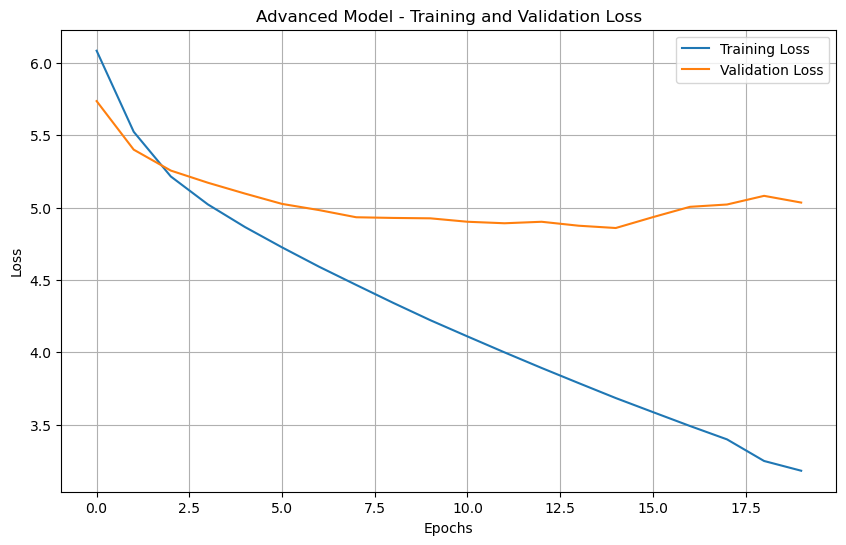

In [54]:
# Initialization
vocab_size = len(vocab)
feature_dim = 5
hidden_dim = 512
num_layers = 4

advanced_model = LyricsMelodyGeneratorAdvanced(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    feature_dim=feature_dim,
    hidden_dim=hidden_dim,
    context_size=context_size,
    num_layers=num_layers,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix,
    vocab=vocab
).to(device)

# Training
trained_advanced_model, adv_train_losses, adv_val_losses = train_advanced_model(
    model=advanced_model,
    train_loader=adv_train_loader,
    val_loader=adv_val_loader,
    epochs=20,
    learning_rate=0.0001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(adv_train_losses, label='Training Loss')
plt.plot(adv_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Advanced Model - Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### 2.4 Evaluation

In [55]:
def generate_lyrics_with_advanced_model(model, midi_data, reverse_vocab, start_words,
                                        max_length=50, temperature=0.8, device='cpu'):
    """Generate lyrics with advanced model."""
    context_size = model.context_size
    generated_lyrics = {}

    for start_word in start_words:

        # Pad context window
        context = ['<START>'] * (context_size - 1) + [start_word]
        lyrics = model.generate_lyrics(
            midi_data=midi_data,
            reverse_vocab=reverse_vocab,
            max_length=max_length,
            start_words=context,
            temperature=temperature,
            device=device,
        )

        # Collapse repeated <NEXT LINE> into one '\n', drop <START>/<END>
        formatted_tokens = []
        prev_was_newline = False
        for token in lyrics:
            if token in ('<START>', '<END>'):
                continue
            elif token == '<NEXT LINE>':
                if not prev_was_newline:
                    formatted_tokens.append('\n')
                    prev_was_newline = True
            else:
                formatted_tokens.append(token)
                prev_was_newline = False

        formatted_text = ' '.join(formatted_tokens)
        formatted_text = formatted_text.replace(' \n', '\n').replace('\n ', '\n')

        generated_lyrics[start_word] = formatted_text.strip()

    return generated_lyrics

In [56]:
start_words = ['<START>', 'love', 'hate']
all_test_results_advanced = {}

for test_item in test_mapping:
    print(f"\nGenerating lyrics for: {test_item['artist']} - {test_item['song']}")

    # Extract melody features
    midi_data = pretty_midi.PrettyMIDI(test_item['midi_file'])

    # Generate lyrics with advanced model
    test_results = generate_lyrics_with_advanced_model(
        model=trained_advanced_model,
        midi_data=midi_data,
        reverse_vocab={v: k for k, v in vocab.items()},
        start_words=start_words,
        max_length=750,
        temperature=0.9,
        device=device,
    )
    all_test_results_advanced[f"{test_item['artist']} - {test_item['song']}"] = test_results

    # Print generated lyrics
    for start_word, lyrics in test_results.items():
        print(f"\nStarting with '{start_word}':")
        print(lyrics)


Generating lyrics for: the_bangles - eternal_flame

Starting with '<START>':
last
she got the night of bop are
that there's the good thing
though you're on the time
that's the one
it's where you mean
i got the sexy way
i'll be the beginning
i'll make you another way
i know that i can't be like
i will say a world of still inside
it's so standin
you should stop all by the blues
you're not just so much no part
you make me linger
you do something can't see me
and all won't only hold me
look down let's know you don't get down
all could you let me go
where the love is a look of my head
oh no could know in my prerogative
yeah baby baby
and could you say my say oh
for my prerogative
i'll love a love
i can't love a chance
where your girl
when can your to read
now how i can be to say
you loved her
you am no deep
i will have you but never loved me
you
when you knew if you know of any time
when i would say you remember it i love you more

Starting with 'love':
love yeah yeah yeah yeah
check me to

## 4. Summary

### 4.1. Comparative Analysis

In [59]:
# Calculate average length of generated lyrics
def avg_length(lyrics_dict):
    total_length = 0
    count = 0
    for song, results in lyrics_dict.items():
        for start_word, lyrics in results.items():
            words = lyrics.split()
            total_length += len(words)
            count += 1
    return total_length / count if count > 0 else 0


simple_avg_length = avg_length(all_test_results_simple)
advanced_avg_length = avg_length(all_test_results_advanced)

print(f"Simple Model - Average Length: {simple_avg_length:.2f} words")
print(f"Advanced Model - Average Length: {advanced_avg_length:.2f} words")

# Display a few sample comparisons
print("\nSample Comparisons:")
common_songs = set(all_test_results_simple.keys()) & set(all_test_results_advanced.keys())
for song in list(common_songs)[:2]:  # Show first 2 common songs
    print(f"\n{song}")
    for start_word in ['<START>']:
        print(f"\nStarting with '{start_word}':")
        if start_word in all_test_results_simple[song]:
            print(f"Simple Model: {all_test_results_simple[song][start_word]}")
        if start_word in all_test_results_advanced[song]:
            print(f"Advanced Model: {all_test_results_advanced[song][start_word]}")

Simple Model - Average Length: 38.87 words
Advanced Model - Average Length: 261.93 words

Sample Comparisons:

the_bangles - eternal_flame

Starting with '<START>':
Simple Model: we may will know i give
in
i
to
a
away
to
oh is
for
closer
Advanced Model: last
she got the night of bop are
that there's the good thing
though you're on the time
that's the one
it's where you mean
i got the sexy way
i'll be the beginning
i'll make you another way
i know that i can't be like
i will say a world of still inside
it's so standin
you should stop all by the blues
you're not just so much no part
you make me linger
you do something can't see me
and all won't only hold me
look down let's know you don't get down
all could you let me go
where the love is a look of my head
oh no could know in my prerogative
yeah baby baby
and could you say my say oh
for my prerogative
i'll love a love
i can't love a chance
where your girl
when can your to read
now how i can be to say
you loved her
you am no deep
i will ha

### 4.2 Save Models and Results

In [61]:
# Save models
torch.save({
    'model_state_dict': trained_model.state_dict(),
    'vocab': vocab,
    'embedding_matrix': embedding_matrix
}, 'simple_lyrics_model.pth')
print("Simple model saved!")

torch.save({
    'model_state_dict': trained_advanced_model.state_dict(),
    'vocab': vocab,
    'embedding_matrix': embedding_matrix
}, 'advanced_lyrics_model.pth')
print("Advanced model saved!")

# Save generated lyrics
with open('generated_lyrics_results.txt', 'w', encoding='utf-8') as f:
    f.write("==== SIMPLE MODEL RESULTS ====\n\n")
    for song, results in all_test_results_simple.items():
        f.write(f"Song: {song}\n")
        for start_word, lyrics in results.items():
            f.write(f"Starting with '{start_word}':\n")
            f.write(f"{lyrics}\n\n")
    f.write("\n\n==== ADVANCED MODEL RESULTS ====\n\n")
    for song, results in all_test_results_advanced.items():
        f.write(f"Song: {song}\n")
        for start_word, lyrics in results.items():
            f.write(f"Starting with '{start_word}':\n")
            f.write(f"{lyrics}\n\n")
print("Generated lyrics results saved to 'generated_lyrics_results.txt'")

Simple model saved!
Advanced model saved!
Generated lyrics results saved to 'generated_lyrics_results.txt'
